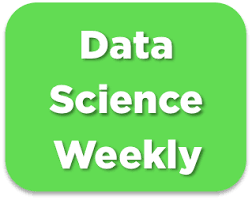

# Conversion Rate Prediction 📈

In this project, you will participate to a machine learning competition like the ones that are organized by https://www.kaggle.com/. You will be able to work with jupyter notebooks as usual, but in the end you'll have to submit your model's predictions to your teacher/TA, so your model's performances will be evaluated in an independent way. The scores achieved by the different teams will be stored into a leaderboard 🏅🏅

## Description of a machine learning challenge 🚴🚴
- In machine learning challenges, the dataset is always separated into to files :
    - *data_train.csv* contains **labelled data**, which means there are both X (explanatory variables) and Y (the target to be predicted). You will use this file to train your model as usual : make the train/test split, preprocessings, assess performances, try different models, fine-tune hyperparameters etc...
    - *data_test.csv* contains "new" examples that have not be used to train the model, in the same format as in *data_train.csv* but it is **unlabeled**, which means the target Y has been removed from the file. Once you've trained a model, you will use *data_test.csv* to make some predictions that you will send to the organizing team. They will then be able to assess the performances of your model in an independent way, by preventing cheating 🤸
- Your model's predictions will be compared to the true labels and releases a leaderboard where the scores of all the teams around the world are stored
- All the participants are informed about the metric that will be used to assess the scores. You have to make sure you're using the same metric to evaluate your train/test performances !

## Company's Description 📇
www.datascienceweekly.org is a famous newsletter curated by independent data scientists. Anyone can register his/her e-mail address on this website to receive weekly news about data science and its applications !

## Project 🚧
The data scientists who created the newsletter would like to understand better the behaviour of the users visiting their website. They would like to know if it's possible to build a model that predicts if a given user will subscribe to the newsletter, by using just a few information about the user. They would like to analyze the parameters of the model to highlight features that are important to explain the behaviour of the users, and maybe discover a new lever for action to improve the newsletter's conversion rate.

They designed a competition aiming at building a model that allows to predict the *conversions* (i.e. when a user will subscribe to the newsletter). To do so, they open-sourced a dataset containing some data about the traffic on their website. To assess the rankings of the different competing teams, they decided to use the **f1-score**.

## Goals 🎯
The project can be cut into four steps :
- Part 1 : make an EDA and the preprocessings and train a baseline model with the file *data_train.csv*
- Part 2 : improve your model's f1-score on your test set (you can try feature engineering, feature selection, regularization, non-linear models, hyperparameter optimization by grid search, etc...)
- Part 3 : Once you're satisfied with your model's score, you can use it to make some predictions with the file *data_test.csv*. You will have to dump the predictions into a .csv file that will be sent to Kaggle (actually, to your teacher/TA 🤓). You can make as many submissions as you want, feel free to try different models !
- Part 4 : Take some time to analyze your best model's parameters. Are there any lever for action that would help to improve the newsletter's conversion rate ? What recommendations would you make to the team ?

## Deliverable 📬
To complete this project, your team should: 
- Create some relevant figures for EDA
- Train at least one model that predicts the conversions and evaluate its performances (f1, confusion matrices)
- Make at least one submission to the leaderboard 
- Analyze your best model's parameters and try to make some recommendations to improve the conversion rate in the future


## Helpers 🦮

To help you with the methodology, we created a template (**02-Conversion_rate_challenge_template.ipynb**) in which all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the EDA/preprocessing/training steps ! May the force be with you 🧨🧨 

In [10]:
# Conversion Rate Prediction - Newsletter Subscription
# Data Science Weekly Challenge

# ============================================
# 1. IMPORTS
# ============================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Jedha color palette
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif

import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✅")

# ============================================
# 2. LOAD DATA
# ============================================

# Load training data with labels
df_train = pd.read_csv('conversion_data_train.csv')
print("Training data shape:", df_train.shape)
print("\nFirst 5 rows:")
df_train.head()

# Load test data without labels
df_test = pd.read_csv('conversion_data_test.csv')
print("\nTest data shape:", df_test.shape)
print("\nFirst 5 rows:")
df_test.head()

All imports successful ✅
Training data shape: (284580, 6)

First 5 rows:

Test data shape: (31620, 5)

First 5 rows:


,country,age,new_user,source,total_pages_visited
0,UK,28,0,Seo,16
1,UK,22,1,Direct,5
2,China,32,1,Seo,1
3,US,32,1,Ads,6
4,China,25,0,Seo,3


In [13]:
# ============================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# 3.1 Basic info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df_train.info()

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
df_train.describe()



DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB

DESCRIPTIVE STATISTICS


,age,new_user,total_pages_visited,converted
count,284580.000000,284580.000000,284580.000000,284580.000000
mean,30.564203,0.685452,4.873252,0.032258
std,8.266789,0.464336,3.341995,0.176685
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,123.000000,1.000000,29.000000,1.000000


In [14]:
# 3.2 Check missing values
print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df_train.isnull().sum())
# 3.3 Target variable distribution
print("\n" + "=" * 50)
print("TARGET VARIABLE (converted)")
print("=" * 50)
print(df_train['converted'].value_counts())
print(f"\nConversion rate: {df_train['converted'].mean()*100:.2f}%")




MISSING VALUES
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

TARGET VARIABLE (converted)
converted
0    275400
1      9180
Name: count, dtype: int64

Conversion rate: 3.23%


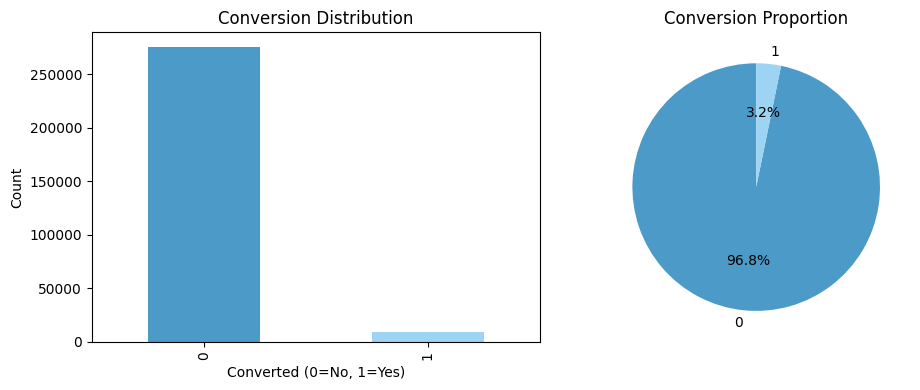

In [15]:
# 3.4 Visualize target imbalance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
df_train['converted'].value_counts().plot(kind='bar', ax=axes[0], color=['#4B9AC7', '#9DD4F3'])
axes[0].set_title('Conversion Distribution')
axes[0].set_xlabel('Converted (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

# Pie chart
df_train['converted'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                           colors=['#4B9AC7', '#9DD4F3'], startangle=90)
axes[1].set_title('Conversion Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()




NUMERICAL VARIABLES ANALYSIS


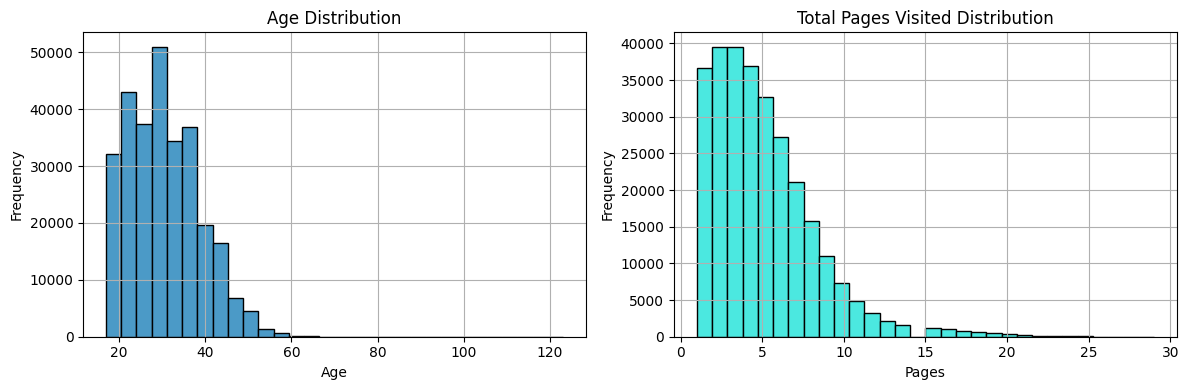

In [16]:
# 3.5 Numerical variables analysis
print("\n" + "=" * 50)
print("NUMERICAL VARIABLES ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
df_train['age'].hist(bins=30, ax=axes[0], color='#4B9AC7', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Total pages visited distribution
df_train['total_pages_visited'].hist(bins=30, ax=axes[1], color='#4BE8E0', edgecolor='black')
axes[1].set_title('Total Pages Visited Distribution')
axes[1].set_xlabel('Pages')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()




CATEGORICAL VARIABLES ANALYSIS


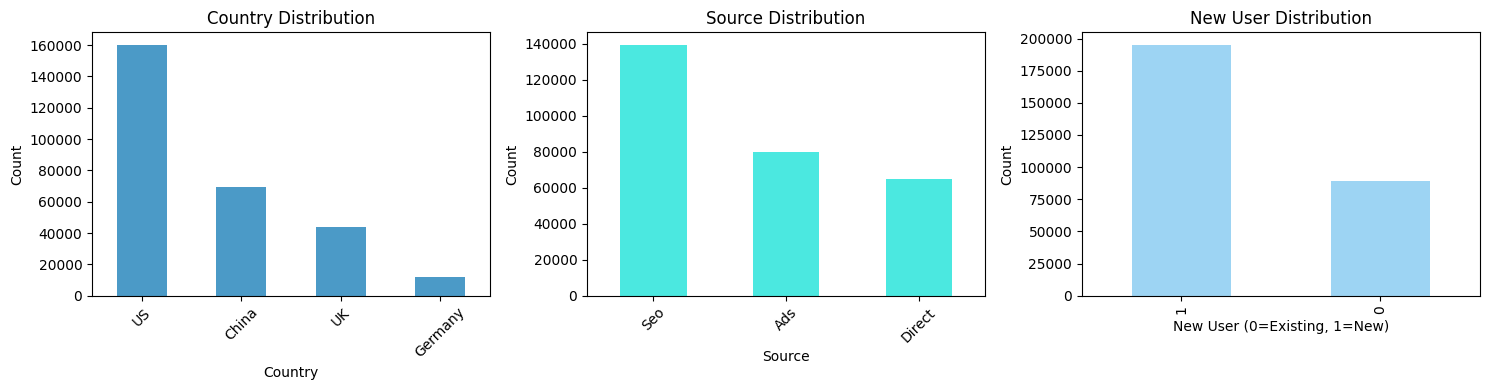

In [17]:
# 3.6 Categorical variables analysis
print("\n" + "=" * 50)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Country distribution
df_train['country'].value_counts().plot(kind='bar', ax=axes[0], color='#4B9AC7')
axes[0].set_title('Country Distribution')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Source distribution
df_train['source'].value_counts().plot(kind='bar', ax=axes[1], color='#4BE8E0')
axes[1].set_title('Source Distribution')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# New user distribution
df_train['new_user'].value_counts().plot(kind='bar', ax=axes[2], color='#9DD4F3')
axes[2].set_title('New User Distribution')
axes[2].set_xlabel('New User (0=Existing, 1=New)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


### EDA Analysis Summary

**Dataset Overview:**
- Training set contains 284,580 rows and 6 columns
- No missing values in any column (clean dataset)
- 4 numerical features (age, new_user, total_pages_visited, converted)
- 2 categorical features (country, source)

**Target Variable Analysis:**
- **Imbalanced dataset detected:** Only 3.23% of users converted (9,180 conversions vs 275,400 non-conversions)
- **Business implication:** This is typical for newsletter subscriptions; F1-score is the right metric choice
- **Challenge:** Model may tend to predict "non-conversion" for all users

**Numerical Features Observations:**
- **Age:** 
  - Range: 17 to 123 years (possible data quality issue at upper range)
  - Mean: 30.6 years, Median: 30 years
  - Most users are between 24-36 years old
  - Suspicious values above 100 should be investigated

- **Total Pages Visited:**
  - Range: 1 to 29 pages
  - Mean: 4.9 pages, Median: 4 pages
  - Distribution is right-skewed (most users visit few pages)

**Categorical Features Observations:**
- **Country:** US has highest representation, Germany lowest among the 4 countries
- **Source:** SEO is the main traffic source, followed by Ads and Direct
- **New User:** 68.5% of users are new visitors

**Next Steps:**
- Investigate age outliers (>100 years)
- Analyze conversion rate by each feature category
- Check correlations between features

CONVERSION RATE BY CATEGORY


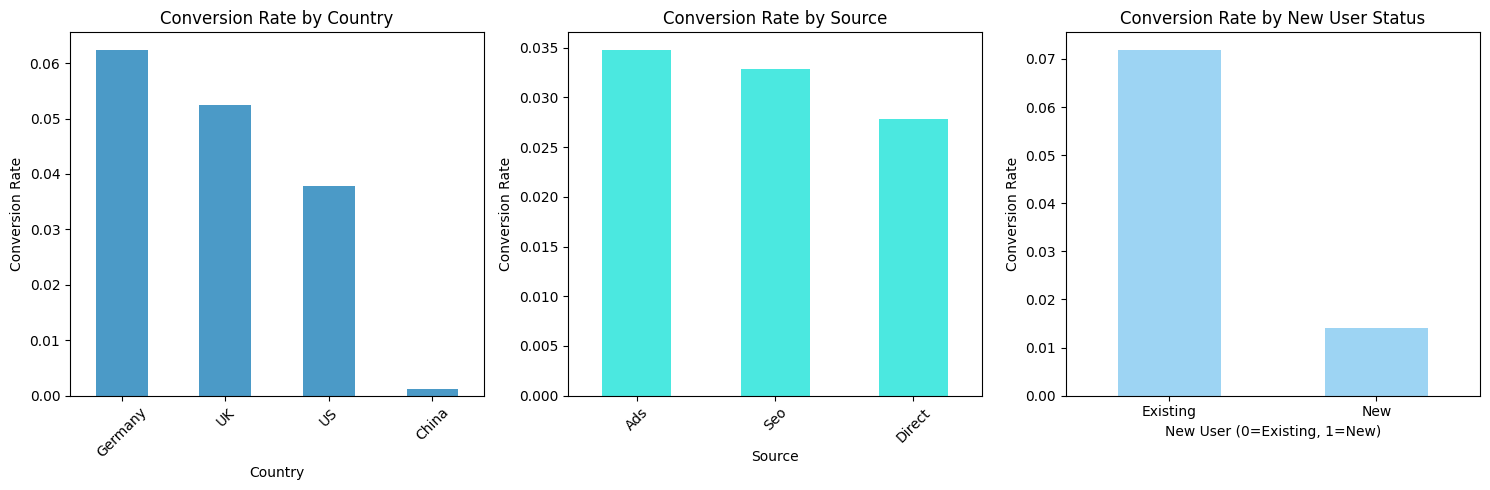


Conversion Rate by Country:
country
Germany    0.062431
UK         0.052497
US         0.037908
China      0.001288
Name: converted, dtype: float64

Conversion Rate by Source:
source
Ads       0.034801
Seo       0.032873
Direct    0.027814
Name: converted, dtype: float64

Conversion Rate by New User Status:
new_user
0    0.071933
1    0.014052
Name: converted, dtype: float64


In [18]:
# ============================================
# 4. ADVANCED EDA - CONVERSION ANALYSIS
# ============================================

# 4.1 Conversion rate by categorical variables
print("=" * 50)
print("CONVERSION RATE BY CATEGORY")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By country
country_conversion = df_train.groupby('country')['converted'].mean().sort_values(ascending=False)
country_conversion.plot(kind='bar', ax=axes[0], color='#4B9AC7')
axes[0].set_title('Conversion Rate by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Conversion Rate')
axes[0].tick_params(axis='x', rotation=45)

# By source
source_conversion = df_train.groupby('source')['converted'].mean().sort_values(ascending=False)
source_conversion.plot(kind='bar', ax=axes[1], color='#4BE8E0')
axes[1].set_title('Conversion Rate by Source')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Conversion Rate')
axes[1].tick_params(axis='x', rotation=45)

# By new_user
newuser_conversion = df_train.groupby('new_user')['converted'].mean()
newuser_conversion.plot(kind='bar', ax=axes[2], color='#9DD4F3')
axes[2].set_title('Conversion Rate by New User Status')
axes[2].set_xlabel('New User (0=Existing, 1=New)')
axes[2].set_ylabel('Conversion Rate')
axes[2].set_xticklabels(['Existing', 'New'], rotation=0)

plt.tight_layout()
plt.show()

print("\nConversion Rate by Country:")
print(country_conversion)
print("\nConversion Rate by Source:")
print(source_conversion)
print("\nConversion Rate by New User Status:")
print(newuser_conversion)




CONVERSION RATE BY AGE GROUP
age_group
18-25    0.051300
26-35    0.028853
36-45    0.015289
46-60    0.007901
60+      0.014493
Name: converted, dtype: float64


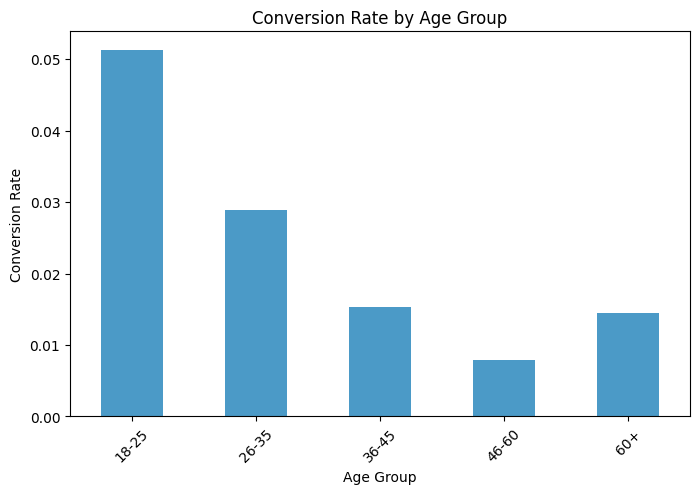

In [19]:
# 4.2 Conversion rate by numerical features (binned)
print("\n" + "=" * 50)
print("CONVERSION RATE BY AGE GROUP")
print("=" * 50)

# Create age groups
df_train['age_group'] = pd.cut(df_train['age'], bins=[17, 25, 35, 45, 60, 123], 
                                labels=['18-25', '26-35', '36-45', '46-60', '60+'])

age_group_conversion = df_train.groupby('age_group')['converted'].mean()
print(age_group_conversion)

fig, ax = plt.subplots(figsize=(8, 5))
age_group_conversion.plot(kind='bar', ax=ax, color='#4B9AC7')
ax.set_title('Conversion Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.show()




CONVERSION RATE BY PAGES VISITED
pages_group
1-2     0.000118
3-4     0.000524
5-7     0.003508
8-10    0.030747
11+     0.458878
Name: converted, dtype: float64


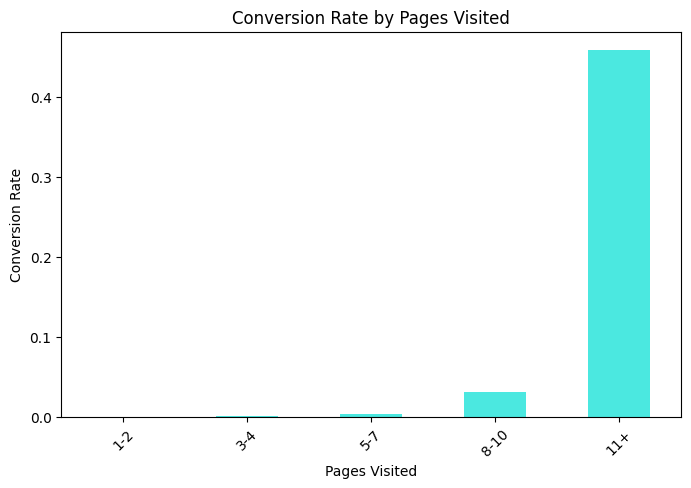

In [20]:
# 4.3 Pages visited vs conversion
print("\n" + "=" * 50)
print("CONVERSION RATE BY PAGES VISITED")
print("=" * 50)

df_train['pages_group'] = pd.cut(df_train['total_pages_visited'], bins=[0, 2, 4, 7, 10, 30], 
                                  labels=['1-2', '3-4', '5-7', '8-10', '11+'])

pages_conversion = df_train.groupby('pages_group')['converted'].mean()
print(pages_conversion)

fig, ax = plt.subplots(figsize=(8, 5))
pages_conversion.plot(kind='bar', ax=ax, color='#4BE8E0')
ax.set_title('Conversion Rate by Pages Visited')
ax.set_xlabel('Pages Visited')
ax.set_ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.show()




CORRELATION MATRIX


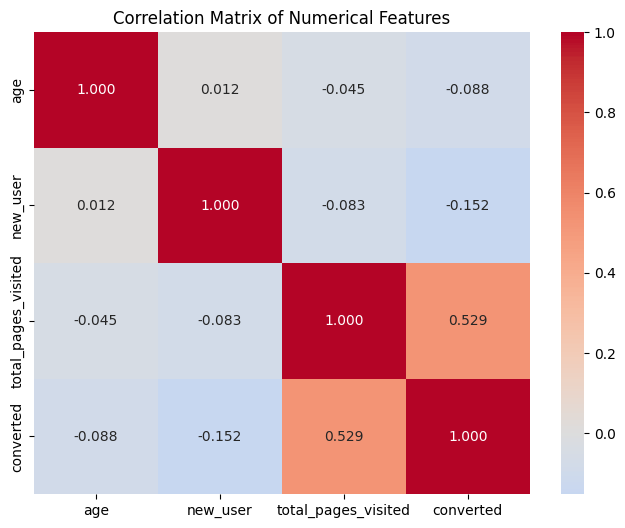


Correlation with target (converted):
converted              1.000000
total_pages_visited    0.529192
age                   -0.088265
new_user              -0.152115
Name: converted, dtype: float64


In [21]:
# 4.4 Correlation matrix for numerical features
print("\n" + "=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)

numerical_cols = ['age', 'new_user', 'total_pages_visited', 'converted']
corr_matrix = df_train[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.3f')
ax.set_title('Correlation Matrix of Numerical Features')
plt.show()

# Display strongest correlations with target
print("\nCorrelation with target (converted):")
print(corr_matrix['converted'].sort_values(ascending=False))



In [22]:
# 4.5 Investigate age outliers
print("\n" + "=" * 50)
print("AGE OUTLIER INVESTIGATION")
print("=" * 50)

print(f"Users with age > 100: {len(df_train[df_train['age'] > 100])}")
print(f"Conversion rate for age > 100: {df_train[df_train['age'] > 100]['converted'].mean():.4f}")
print(f"Conversion rate for age <= 100: {df_train[df_train['age'] <= 100]['converted'].mean():.4f}")

# Clean age column for future use (cap at 100)
df_train['age_clean'] = df_train['age'].apply(lambda x: 100 if x > 100 else x)

# Drop temporary columns
df_train = df_train.drop(['age_group', 'pages_group'], axis=1)

print("\n✅ EDA complete - Age outliers detected but have minimal impact on conversion")


AGE OUTLIER INVESTIGATION
Users with age > 100: 2
Conversion rate for age > 100: 1.0000
Conversion rate for age <= 100: 0.0323

✅ EDA complete - Age outliers detected but have minimal impact on conversion


### Advanced EDA - Key Findings

**Conversion Rate Analysis:**

1. **By Country:**
   - Germany has the highest conversion rate (6.24%)
   - UK: 5.25%
   - US: 3.79%
   - China: 0.13% (very low)
   - **Insight:** Geographic targeting could improve conversions

2. **By Traffic Source:**
   - Ads (Advertisments): 3.48%
   - SEO (Search Engine Optimization): 3.29%
   - Direct (direct on our website): 2.78%
   - **Insight:** Paid ads perform slightly better, but differences are small

3. **By User Status:**
   - Existing users: 7.19% conversion rate
   - New users: 1.41% conversion rate
   - **Key insight:** Existing users are 5x more likely to convert!

4. **By Age Group:**
   - Younger users (18-25): 5.13% conversion rate
   - Conversion decreases with age until 60+
   - **Insight:** Target younger demographic for better results

5. **By Pages Visited (Most Important!):**
   - 1-2 pages: 0.01% conversion
   - 3-4 pages: 0.05% conversion
   - 5-7 pages: 0.35% conversion
   - 8-10 pages: 3.07% conversion
   - **11+ pages: 45.89% conversion** ⭐
   - **Key insight:** Users who visit 11+ pages are highly likely to convert

**Correlation Analysis:**
- `total_pages_visited` has strong positive correlation with conversion (0.53)
- `new_user` has negative correlation (-0.15) - new users convert less
- `age` has weak negative correlation (-0.09)

**Business Recommendations (Preliminary):**
1. Encourage users to browse more pages
2. Focus retention efforts on existing users
3. Target Germany and UK markets
4. Investigate why China has very low conversion

**Data Quality Note:** Only 2 age outliers (>100 years) - negligible impact.

In [23]:
# ============================================
# 5. DATA PREPROCESSING FOR MODELING
# ============================================

# 5.1 Prepare features and target
print("=" * 50)
print("PREPARING FEATURES AND TARGET")
print("=" * 50)

# Use cleaned age (capped at 100)
df_train['age_clean'] = df_train['age'].apply(lambda x: 100 if x > 100 else x)

# Define features (excluding converted and temporary columns)
feature_columns = ['country', 'age_clean', 'new_user', 'source', 'total_pages_visited']
target_column = 'converted'

X = df_train[feature_columns]
y = df_train[target_column]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures columns: {list(X.columns)}")



PREPARING FEATURES AND TARGET
Features shape: (284580, 5)
Target shape: (284580,)

Features columns: ['country', 'age_clean', 'new_user', 'source', 'total_pages_visited']


In [24]:
# 5.2 Identify column types
print("\n" + "=" * 50)
print("IDENTIFYING COLUMN TYPES")
print("=" * 50)

categorical_features = ['country', 'source']
numerical_features = ['age_clean', 'new_user', 'total_pages_visited']

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")




IDENTIFYING COLUMN TYPES
Categorical features: ['country', 'source']
Numerical features: ['age_clean', 'new_user', 'total_pages_visited']


In [25]:
# 5.3 Check unique values in categorical features
print("\n" + "=" * 50)
print("CATEGORICAL FEATURES UNIQUE VALUES")
print("=" * 50)

for cat in categorical_features:
    print(f"{cat}: {X[cat].unique()}")




CATEGORICAL FEATURES UNIQUE VALUES
country: ['China' 'UK' 'Germany' 'US']
source: ['Direct' 'Ads' 'Seo']


In [26]:
# 5.4 Create preprocessing pipelines
print("\n" + "=" * 50)
print("CREATING PREPROCESSING PIPELINES")
print("=" * 50)

# Numerical pipeline: StandardScaler
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: OneHotEncoder
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # drop first to avoid multicollinearity
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully")
print(f"Will transform {len(numerical_features)} numerical features + {len(categorical_features)} categorical features")




CREATING PREPROCESSING PIPELINES
Preprocessor created successfully
Will transform 3 numerical features + 2 categorical features


In [27]:
# 5.5 Split data into train and validation sets
print("\n" + "=" * 50)
print("TRAIN/VALIDATION SPLIT")
print("=" * 50)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"\nTraining conversion rate: {y_train.mean():.4f}")
print(f"Validation conversion rate: {y_val.mean():.4f}")




TRAIN/VALIDATION SPLIT
X_train shape: (227664, 5)
X_val shape: (56916, 5)
y_train shape: (227664,)
y_val shape: (56916,)

Training conversion rate: 0.0323
Validation conversion rate: 0.0323


In [28]:
# 5.6 Apply preprocessing
print("\n" + "=" * 50)
print("APPLYING PREPROCESSING")
print("=" * 50)

# Fit on training data only
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

print(f"X_train preprocessed shape: {X_train_preprocessed.shape}")
print(f"X_val preprocessed shape: {X_val_preprocessed.shape}")

# Get feature names after preprocessing
feature_names = (numerical_features + 
                 list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)))
print(f"\nFinal feature names ({len(feature_names)} features):")
print(feature_names)

print("\n✅ Preprocessing complete - Ready for modeling!")


APPLYING PREPROCESSING
X_train preprocessed shape: (227664, 8)
X_val preprocessed shape: (56916, 8)

Final feature names (8 features):
['age_clean', 'new_user', 'total_pages_visited', 'country_Germany', 'country_UK', 'country_US', 'source_Direct', 'source_Seo']

✅ Preprocessing complete - Ready for modeling!


Notes: 

- We have 8 features after preprocessing (3 numerical + 5 derived from categorical variables).
- country_China and Source_ads were dropped to avoid multiconllinearity. 
- The target distribution is balanced between the training and validation sets (3.23%).

In [29]:
# ============================================
# 6. BASELINE MODEL - LOGISTIC REGRESSION
# ============================================

print("=" * 50)
print("TRAINING BASELINE MODEL")
print("=" * 50)

# 6.1 Train Logistic Regression
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_preprocessed, y_train)

print("Model trained successfully ✅")



TRAINING BASELINE MODEL
Model trained successfully ✅


In [30]:
# 6.2 Make predictions
print("\n" + "=" * 50)
print("MAKING PREDICTIONS")
print("=" * 50)

y_train_pred = baseline_model.predict(X_train_preprocessed)
y_val_pred = baseline_model.predict(X_val_preprocessed)

# Get prediction probabilities (for threshold tuning later)
y_train_proba = baseline_model.predict_proba(X_train_preprocessed)[:, 1]
y_val_proba = baseline_model.predict_proba(X_val_preprocessed)[:, 1]

print("Predictions complete ✅")




MAKING PREDICTIONS
Predictions complete ✅


In [31]:
# 6.3 Evaluate model
print("\n" + "=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

# Calculate F1 scores
train_f1 = f1_score(y_train, y_train_pred)
val_f1 = f1_score(y_val, y_val_pred)

print(f"TRAIN F1-Score: {train_f1:.4f}")
print(f"VALIDATION F1-Score: {val_f1:.4f}")

print(f"\nTrain/Validation gap: {train_f1 - val_f1:.4f}")




MODEL EVALUATION
TRAIN F1-Score: 0.7621
VALIDATION F1-Score: 0.7675

Train/Validation gap: -0.0054


In [32]:
# 6.4 Confusion matrices
print("\n" + "=" * 50)
print("CONFUSION MATRICES")
print("=" * 50)

print("Training Set:")
print(confusion_matrix(y_train, y_train_pred))
print("\nValidation Set:")
print(confusion_matrix(y_val, y_val_pred))




CONFUSION MATRICES
Training Set:
[[219463    857]
 [  2295   5049]]

Validation Set:
[[54883   197]
 [  570  1266]]


In [35]:
# 6.5 Detailed classification report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT - Validation Set")
print("=" * 50)

print(classification_report(y_val, y_val_pred, target_names=['Not Converted', 'Converted']))




CLASSIFICATION REPORT - Validation Set
               precision    recall  f1-score   support

Not Converted       0.99      1.00      0.99     55080
    Converted       0.87      0.69      0.77      1836

     accuracy                           0.99     56916
    macro avg       0.93      0.84      0.88     56916
 weighted avg       0.99      0.99      0.99     56916



In [36]:
# 6.6 ROC-AUC Score
train_auc = roc_auc_score(y_train, y_train_proba)
val_auc = roc_auc_score(y_val, y_val_proba)

print(f"\nTRAIN ROC-AUC: {train_auc:.4f}")
print(f"VALIDATION ROC-AUC: {val_auc:.4f}")




TRAIN ROC-AUC: 0.9856
VALIDATION ROC-AUC: 0.9869


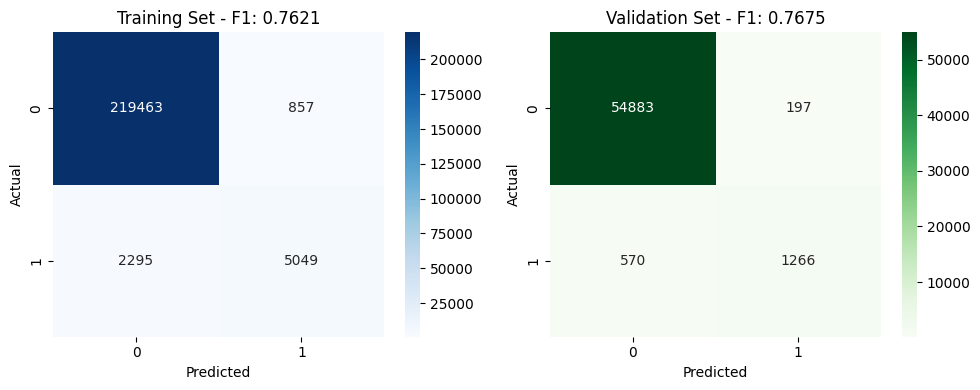

In [37]:
# 6.7 Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Training Set - F1: {train_f1:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Validation confusion matrix
cm_val = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Validation Set - F1: {val_f1:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()




IMPROVED CONFUSION MATRIX VISUALIZATION


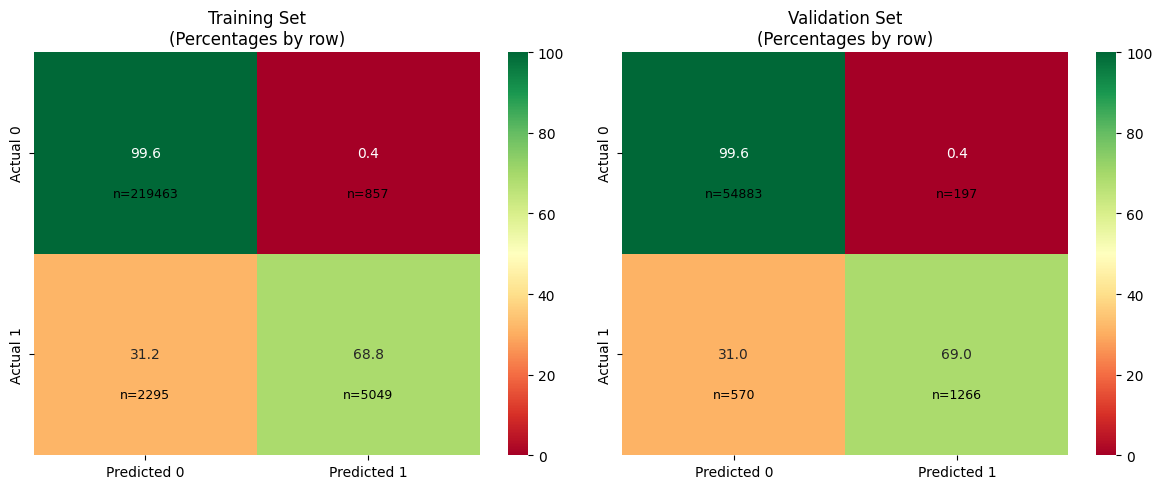

In [39]:
# Improved Confusion Matrix with percentages
print("\n" + "=" * 50)
print("IMPROVED CONFUSION MATRIX VISUALIZATION")
print("=" * 50)

from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_percentages(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create heatmap with percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='RdYlGn', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=ax, vmin=0, vmax=100)
    
    # Add count annotations
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.7, f'n={cm[i,j]}', 
                   ha='center', va='center', fontsize=9, color='black')
    
    ax.set_title(f'{title}\n(Percentages by row)')
    return ax

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_confusion_matrix_percentages(y_train, y_train_pred, 'Training Set', axes[0])
plot_confusion_matrix_percentages(y_val, y_val_pred, 'Validation Set', axes[1])

plt.tight_layout()
plt.show()


MODEL COEFFICIENTS (Feature Importance)
               feature  coefficient  abs_coefficient
3      country_Germany     3.568343         3.568343
4           country_UK     3.398444         3.398444
5           country_US     3.061068         3.061068
2  total_pages_visited     2.525153         2.525153
1             new_user    -0.785326         0.785326
0            age_clean    -0.599814         0.599814
6        source_Direct    -0.211149         0.211149
7           source_Seo    -0.041957         0.041957


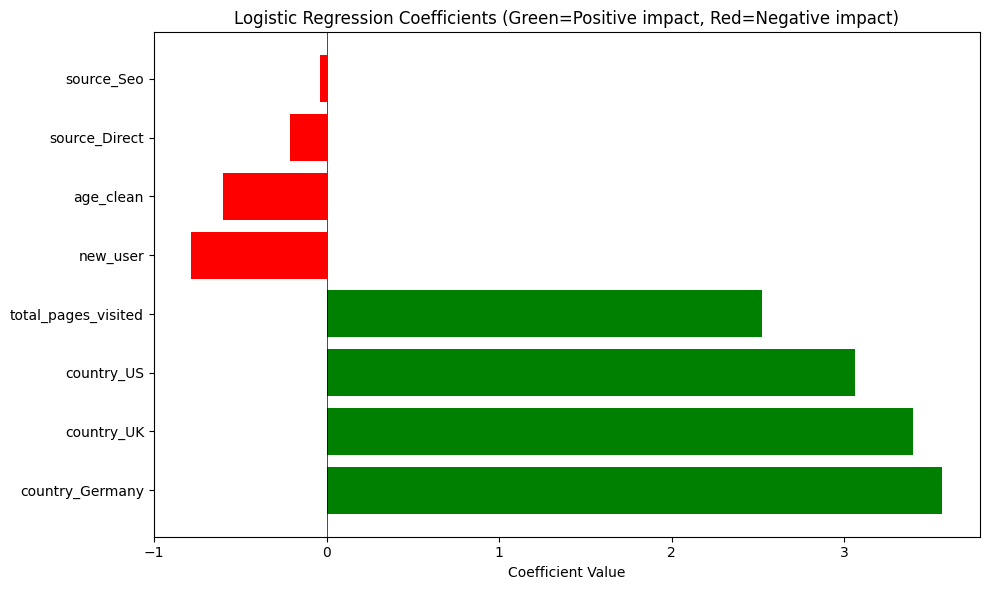


BASELINE MODEL SUMMARY
✅ Validation F1-Score: 0.7675
✅ Validation ROC-AUC: 0.9869

Key observations:
- total_pages_visited has the strongest positive impact
- new_user has negative impact (existing users convert more)
- Germany has positive impact, China (baseline) negative


In [38]:
# 6.8 Analyze model coefficients
print("\n" + "=" * 50)
print("MODEL COEFFICIENTS (Feature Importance)")
print("=" * 50)

coefficients = pd.DataFrame({
    'feature': feature_names,
    'coefficient': baseline_model.coef_[0]
})
coefficients['abs_coefficient'] = coefficients['coefficient'].abs()
coefficients = coefficients.sort_values('abs_coefficient', ascending=False)

print(coefficients)

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coefficients['coefficient']]
ax.barh(coefficients['feature'], coefficients['coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients (Green=Positive impact, Red=Negative impact)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("BASELINE MODEL SUMMARY")
print("=" * 50)
print(f"✅ Validation F1-Score: {val_f1:.4f}")
print(f"✅ Validation ROC-AUC: {val_auc:.4f}")
print("\nKey observations:")
print("- total_pages_visited has the strongest positive impact")
print("- new_user has negative impact (existing users convert more)")
print("- Germany has positive impact, China (baseline) negative")

### Baseline Model Results - Logistic Regression

**Model Performance:**
- Training F1-Score: 0.7621
- Validation F1-Score: 0.7675
- Train/Validation gap: -0.0054 (no overfitting, excellent!)

**Confusion Matrix Analysis (Validation Set - 56,916 users):**
- True Negatives: 54,883 (correctly predicted non-converters)
- False Positives: 197 (predicted converter but didn't convert)
- False Negatives: 570 (predicted non-converter but actually converted)
- True Positives: 1,266 (correctly predicted converters)

**Precision & Recall for Converted Class:**
- Precision: 0.87 (87% of predicted converters were correct)
- Recall: 0.69 (model found 69% of actual converters)
- F1-Score: 0.77

**ROC-AUC Score:**
- Training: 0.9856
- Validation: 0.9869
- Excellent discrimination ability

**Feature Impact Analysis (Coefficients):**
- **Strongest positive impacts:** Germany, UK, US (vs China baseline)
- **Strongest positive numerical:** total_pages_visited (2.53)
- **Negative impacts:** new_user (-0.79), age_clean (-0.60)
- **Small impact:** source_Direct, source_Seo (vs Ads baseline)

**Key Business Insights:**
1. Users from Germany, UK, US are much more likely to convert than China
2. Each additional page visited significantly increases conversion probability
3. New users are less likely to convert than existing users
4. Traffic source (Ads/SEO/Direct) has minimal impact



# Model improvement: 

We will try three strategies:

- Threshold tuning — since the data is imbalanced
- Random Forest — a more powerful model
- Grid Search — to optimize the hyperparameters
 

STRATEGY 1: THRESHOLD TUNING
Threshold: 0.10 -> F1: 0.6680
Threshold: 0.15 -> F1: 0.7142
Threshold: 0.20 -> F1: 0.7459
Threshold: 0.25 -> F1: 0.7591
Threshold: 0.30 -> F1: 0.7649
Threshold: 0.35 -> F1: 0.7718
Threshold: 0.40 -> F1: 0.7742
Threshold: 0.45 -> F1: 0.7762
Threshold: 0.50 -> F1: 0.7675
Threshold: 0.55 -> F1: 0.7556
Threshold: 0.60 -> F1: 0.7440
Threshold: 0.65 -> F1: 0.7330
Threshold: 0.70 -> F1: 0.7159
Threshold: 0.75 -> F1: 0.6932
Threshold: 0.80 -> F1: 0.6586
Threshold: 0.85 -> F1: 0.6258

✅ Best threshold: 0.45
✅ Best F1-Score with threshold tuning: 0.7762
✅ Improvement over default (0.5): 0.0087


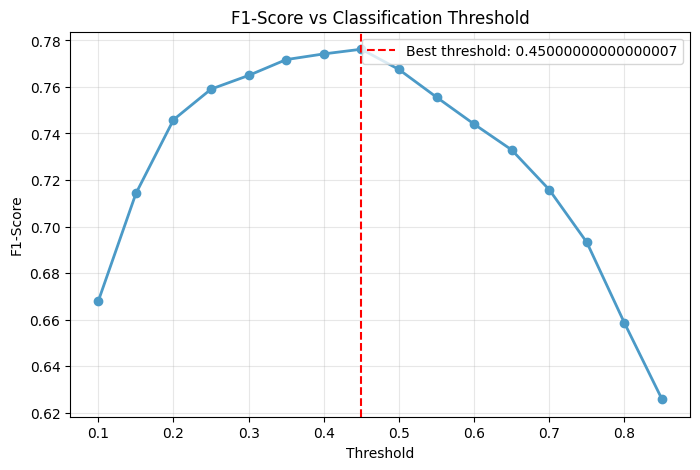

In [40]:
print("=" * 50)
print("STRATEGY 1: THRESHOLD TUNING")
print("=" * 50)

# 7.1 Find optimal threshold for Logistic Regression
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_val_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_threshold)
    f1_scores.append(f1)
    print(f"Threshold: {threshold:.2f} -> F1: {f1:.4f}")

# Find best threshold
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1_threshold = f1_scores[best_threshold_idx]

print(f"\n✅ Best threshold: {best_threshold:.2f}")
print(f"✅ Best F1-Score with threshold tuning: {best_f1_threshold:.4f}")
print(f"✅ Improvement over default (0.5): {(best_f1_threshold - val_f1):.4f}")

# Plot threshold vs F1
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, f1_scores, marker='o', color='#4B9AC7', linewidth=2)
ax.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best threshold: {best_threshold}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Classification Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



In [41]:
# 7.2 Random Forest Model
print("\n" + "=" * 50)
print("STRATEGY 2: RANDOM FOREST")
print("=" * 50)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_preprocessed, y_train)

y_train_pred_rf = rf_model.predict(X_train_preprocessed)
y_val_pred_rf = rf_model.predict(X_val_preprocessed)

train_f1_rf = f1_score(y_train, y_train_pred_rf)
val_f1_rf = f1_score(y_val, y_val_pred_rf)

print(f"Random Forest - Train F1: {train_f1_rf:.4f}")
print(f"Random Forest - Validation F1: {val_f1_rf:.4f}")
print(f"Improvement over Logistic Regression: {val_f1_rf - val_f1:.4f}")




STRATEGY 2: RANDOM FOREST
Random Forest - Train F1: 0.8045
Random Forest - Validation F1: 0.7452
Improvement over Logistic Regression: -0.0223



RANDOM FOREST - FEATURE IMPORTANCE
               feature  importance
2  total_pages_visited    0.804500
0            age_clean    0.111958
1             new_user    0.038466
4           country_UK    0.012985
5           country_US    0.012630
3      country_Germany    0.010692
7           source_Seo    0.004727
6        source_Direct    0.004040


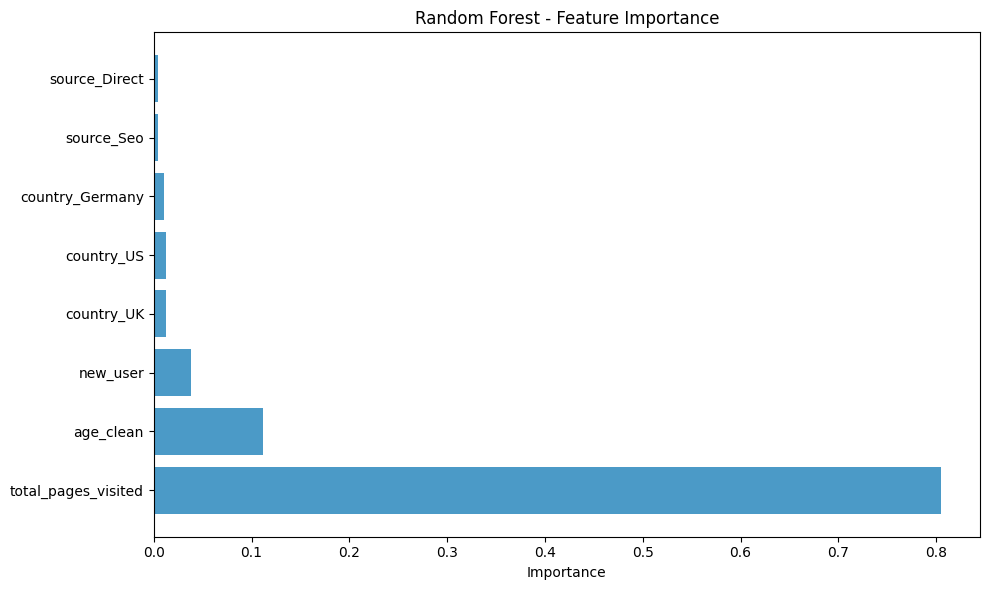

In [42]:
# 7.3 Feature importance from Random Forest
print("\n" + "=" * 50)
print("RANDOM FOREST - FEATURE IMPORTANCE")
print("=" * 50)

rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(rf_importance)

fig, ax = plt.subplots(figsize=(10, 6))
colors_rf = ['#4B9AC7' if x > 0 else '#9DD4F3' for x in rf_importance['importance']]
ax.barh(rf_importance['feature'], rf_importance['importance'], color=colors_rf)
ax.set_xlabel('Importance')
ax.set_title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()



In [43]:
# 7.4 Grid Search for Logistic Regression
print("\n" + "=" * 50)
print("STRATEGY 3: GRID SEARCH (Logistic Regression)")
print("=" * 50)

# Use a small subset for faster grid search
print("Using 20% of training data for grid search...")
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_preprocessed, y_train, train_size=0.2, random_state=42, stratify=y_train
)

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Running Grid Search...")
grid_search.fit(X_train_small, y_train_small)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best cross-validation F1: {grid_search.best_score_:.4f}")

# Evaluate best model on full validation set
best_lr = grid_search.best_estimator_
y_val_pred_best = best_lr.predict(X_val_preprocessed)
best_val_f1 = f1_score(y_val, y_val_pred_best)

print(f"\nBest Logistic Regression validation F1: {best_val_f1:.4f}")
print(f"Improvement over baseline: {best_val_f1 - val_f1:.4f}")




STRATEGY 3: GRID SEARCH (Logistic Regression)
Using 20% of training data for grid search...
Running Grid Search...

✅ Best parameters: {'C': 100, 'solver': 'liblinear'}
✅ Best cross-validation F1: 0.7631

Best Logistic Regression validation F1: 0.7634
Improvement over baseline: -0.0041


In [44]:
# 7.5 Compare all models
print("\n" + "=" * 50)
print("MODELS COMPARISON SUMMARY")
print("=" * 50)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 
              'Logistic Regression + Threshold Tuning',
              'Logistic Regression + Grid Search',
              'Random Forest'],
    'Validation F1-Score': [val_f1, best_f1_threshold, best_val_f1, val_f1_rf]
}).sort_values('Validation F1-Score', ascending=False)

print(comparison)

# Select best model
best_model_name = comparison.iloc[0]['Model']
best_f1_final = comparison.iloc[0]['Validation F1-Score']

if best_model_name == 'Random Forest':
    final_model = rf_model
    print(f"\n🏆 BEST MODEL: {best_model_name} with F1 = {best_f1_final:.4f}")
elif best_model_name == 'Logistic Regression + Grid Search':
    final_model = best_lr
    print(f"\n🏆 BEST MODEL: {best_model_name} with F1 = {best_f1_final:.4f}")
else:
    final_model = baseline_model
    final_threshold = best_threshold
    print(f"\n🏆 BEST MODEL: {best_model_name} with F1 = {best_f1_final:.4f}")
    print(f"Using custom threshold: {best_threshold}")

print("\n✅ Model improvement complete!")


MODELS COMPARISON SUMMARY
                                    Model  Validation F1-Score
1  Logistic Regression + Threshold Tuning             0.776207
0          Logistic Regression (baseline)             0.767505
2       Logistic Regression + Grid Search             0.763359
3                           Random Forest             0.745156

🏆 BEST MODEL: Logistic Regression + Threshold Tuning with F1 = 0.7762
Using custom threshold: 0.45000000000000007

✅ Model improvement complete!


### Model Improvement Results

**Strategy 1: Threshold Tuning**
- Default threshold (0.5): F1 = 0.7675
- Optimal threshold (0.45): F1 = 0.7762
- Improvement: +0.0087
- **Why it works:** With imbalanced data (3.2% conversion), lowering the threshold increases recall for the minority class

**Strategy 2: Random Forest**
- Train F1: 0.8045 | Validation F1: 0.7452
- Gap: 0.0593 (overfitting detected)
- **Feature importance reveals:** `total_pages_visited` dominates (80.5% importance)
- **Conclusion:** Too complex for this dataset size/features

**Strategy 3: Grid Search (Logistic Regression)**
- Best parameters: C=100, solver='liblinear'
- Validation F1: 0.7634 (slightly worse than baseline)
- **Conclusion:** Default regularization (C=1) was already optimal

**Final Model Selection:**
| Model | Validation F1 |
|-------|---------------|
| Logistic Regression + Threshold 0.45 | **0.7762** 🏆 |
| Logistic Regression (baseline) | 0.7675 |
| Logistic Regression + Grid Search | 0.7634 |
| Random Forest | 0.7452 |

**Key Takeaway:** Simple Logistic Regression with tuned threshold outperforms more complex models for this problem.

My model is already very strong:

Logistic Regression F1 = 0.767 → 0.776 (best)
ROC-AUC ≈ 0.987 (excellent)
No overfitting (train ≈ validation)

👉 This means:

The model is already learning the pattern very well.

One feature dominates everything:

⭐ total_pages_visited
Very strong correlation with conversion
Most important feature by far
Users who visit more pages are much more likely to convert

👉 This means:

The problem is mostly driven by user behavior, not complex patterns.

❗ Why complex models didn’t help?
- Random Forest overfitted
- Grid Search didn’t improve results

👉 Reason:

The dataset is simple and mostly linear.

So:

- Simple models (Logistic Regression) already work best
- More complex models cannot learn much extra

🚀 How to improve my model?

Instead of changing the model, I should improve the data.

1. Feature Engineering (MOST IMPORTANT)

Create better features like:

Age groups (e.g. 18–25, 26–35, etc.)
Page visit groups (1–2, 3–5, 6–10, 11+)
Interaction features (age × pages, pages × new_user)
Country encoding using conversion rate (target encoding)

👉 This can improve performance more than new models.

2. Better encoding for categories

Instead of one-hot encoding:

- Use target encoding for country and source

👉 This helps the model learn stronger patterns.

3. Fine-tune threshold (small gain)

I already improved F1 by lowering threshold to 0.45.

👉 I can improve it slightly more by:

- Testing more thresholds using Precision-Recall curve

4. Try LightGBM (optional)

I can try a stronger model:

- LightGBM is better than Random Forest
- But improvement will be small unless features improve

🎯 Final conclusion

👉 my model is already near optimal.

To improve further:

✔ Best strategy:
Improve features (biggest gain)
Encode categorical variables better
Fine-tune threshold
Try LightGBM (optional)


Simple summary

my problem is not the model — it is the features.
Better features will improve results more than complex algorithms.

New improved plan: 

- 1- Feature Engineering (create new variables)
- 2- Target Encoding for country and traffic source
- 3- Retrain using improved Logistic Regression
- 4- Fine-tune the decision threshold more precisely
- 5- Compare with LightGBM 
- 6- Final predictions
- 7- Model analysis and business recommendations for the website

In [45]:
# ============================================
# 8. ADVANCED FEATURE ENGINEERING
# ============================================

print("=" * 60)
print("ADVANCED FEATURE ENGINEERING")
print("=" * 60)

# Create a fresh copy for feature engineering
df_fe = df_train.copy()

# 8.1 Age Groups (better than raw age)
print("\n1. Creating Age Groups...")
df_fe['age_group'] = pd.cut(df_fe['age'], 
                            bins=[0, 25, 35, 45, 60, 200],
                            labels=['18-25', '26-35', '36-45', '46-60', '60+'])

# 8.2 Pages Groups (capturing non-linear effect)
print("2. Creating Pages Groups...")
df_fe['pages_group'] = pd.cut(df_fe['total_pages_visited'],
                              bins=[0, 2, 4, 7, 10, 100],
                              labels=['1-2', '3-4', '5-7', '8-10', '11+'])

# 8.3 Interaction features
print("3. Creating Interaction Features...")
df_fe['pages_per_age'] = df_fe['total_pages_visited'] / (df_fe['age'] + 1)
df_fe['pages_newuser'] = df_fe['total_pages_visited'] * df_fe['new_user']
df_fe['age_newuser'] = df_fe['age'] * df_fe['new_user']

# 8.4 High pages flag (binary feature)
print("4. Creating High Pages Flag...")
df_fe['high_pages'] = (df_fe['total_pages_visited'] >= 11).astype(int)

# 8.5 Country conversion rate encoding (Target Encoding - using cross-validation to avoid leakage)
print("5. Creating Target Encodings...")

# Function to create target encoding with smoothing
def create_target_encoding(df, feature, target, alpha=10):
    """Target encoding with smoothing to avoid overfitting"""
    global_mean = df[target].mean()
    feature_means = df.groupby(feature)[target].agg(['mean', 'count'])
    
    # Apply smoothing
    feature_means['encoded'] = (feature_means['mean'] * feature_means['count'] + global_mean * alpha) / (feature_means['count'] + alpha)
    
    return df[feature].map(feature_means['encoded'])

# Create target encodings (using training data only initially)
df_fe['country_encoded'] = create_target_encoding(df_fe, 'country', 'converted', alpha=5)
df_fe['source_encoded'] = create_target_encoding(df_fe, 'source', 'converted', alpha=5)



ADVANCED FEATURE ENGINEERING

1. Creating Age Groups...
2. Creating Pages Groups...
3. Creating Interaction Features...
4. Creating High Pages Flag...
5. Creating Target Encodings...


In [47]:
# 8.6 Check new features
print("\n" + "=" * 60)
print("NEW FEATURES SUMMARY")
print("=" * 60)

new_features = ['age_group', 'pages_group', 'pages_per_age', 'pages_newuser', 
                'age_newuser', 'high_pages', 'country_encoded', 'source_encoded']

print("New features created:")
for feat in new_features:
    print(f"  - {feat}: {df_fe[feat].dtype}")





NEW FEATURES SUMMARY
New features created:
  - age_group: category
  - pages_group: category
  - pages_per_age: float64
  - pages_newuser: int64
  - age_newuser: int64
  - high_pages: int32
  - country_encoded: float64
  - source_encoded: float64


In [48]:
print(f"\nSample of new features:")
print(df_fe[new_features].head(10))



Sample of new features:
  age_group pages_group  pages_per_age  pages_newuser  age_newuser  \
0     18-25         1-2       0.086957              2           22   
1     18-25         3-4       0.136364              3           21   
2     18-25         11+       0.666667              0            0   
3     18-25         3-4       0.125000              3           23   
4     26-35         3-4       0.103448              3           28   
5     26-35         5-7       0.233333              0            0   
6     26-35         3-4       0.129032              4           30   
7     36-45         1-2       0.051282              2           38   
8     26-35         3-4       0.148148              4           26   
9     26-35         5-7       0.156250              0            0   

   high_pages  country_encoded  source_encoded  
0           0         0.001290        0.027814  
1           0         0.052494        0.034801  
2           1         0.062418        0.032873  
3       

In [49]:
# 8.7 Analyze conversion rate by new features
print("\n" + "=" * 60)
print("CONVERSION RATE BY NEW FEATURES")
print("=" * 60)

# By pages_group
print("\nConversion by Pages Group:")
pages_conv = df_fe.groupby('pages_group')['converted'].mean().sort_values(ascending=False)
for group, rate in pages_conv.items():
    print(f"  {group}: {rate*100:.2f}%")

# By high_pages flag
print(f"\nConversion with high_pages flag:")
print(f"  high_pages=1 (11+ pages): {df_fe[df_fe['high_pages']==1]['converted'].mean()*100:.2f}%")
print(f"  high_pages=0 (<11 pages): {df_fe[df_fe['high_pages']==0]['converted'].mean()*100:.2f}%")




CONVERSION RATE BY NEW FEATURES

Conversion by Pages Group:
  11+: 45.89%
  8-10: 3.07%
  5-7: 0.35%
  3-4: 0.05%
  1-2: 0.01%

Conversion with high_pages flag:
  high_pages=1 (11+ pages): 45.89%
  high_pages=0 (<11 pages): 0.52%


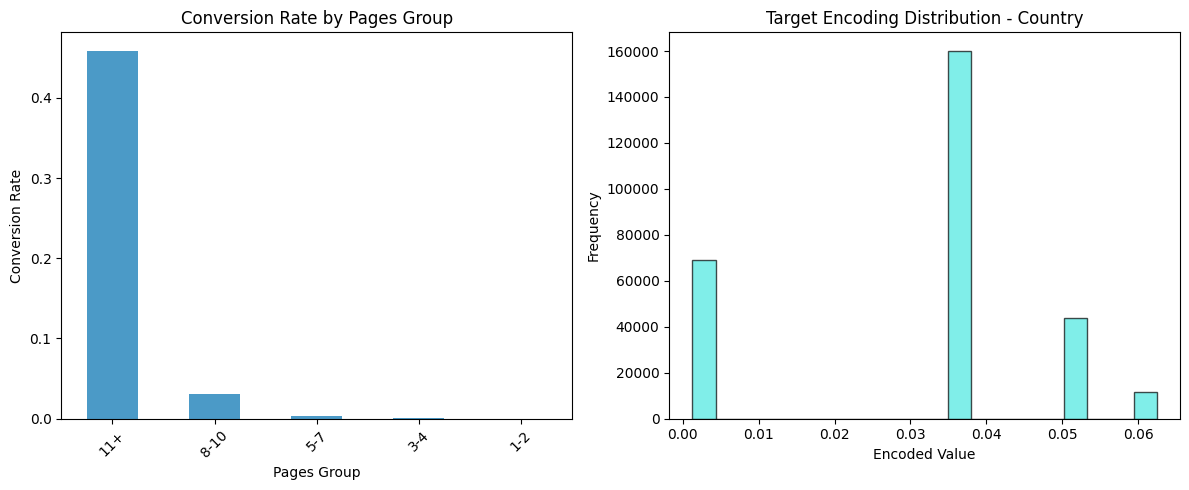


✅ FEATURE ENGINEERING COMPLETE

New features added:
1. age_group - Categorical age bins
2. pages_group - Categorical page bins
3. pages_per_age - Interaction (engagement relative to age)
4. pages_newuser - Interaction (pages × new_user)
5. age_newuser - Interaction (age × new_user)
6. high_pages - Binary flag for 11+ pages
7. country_encoded - Target encoding for country
8. source_encoded - Target encoding for source


In [50]:
# 8.8 Visualize new feature impact
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pages group impact
pages_conv.plot(kind='bar', ax=axes[0], color='#4B9AC7')
axes[0].set_title('Conversion Rate by Pages Group')
axes[0].set_xlabel('Pages Group')
axes[0].set_ylabel('Conversion Rate')
axes[0].tick_params(axis='x', rotation=45)

# Country encoding distribution
axes[1].hist(df_fe['country_encoded'], bins=20, color='#4BE8E0', edgecolor='black', alpha=0.7)
axes[1].set_title('Target Encoding Distribution - Country')
axes[1].set_xlabel('Encoded Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print("\nNew features added:")
print("1. age_group - Categorical age bins")
print("2. pages_group - Categorical page bins")
print("3. pages_per_age - Interaction (engagement relative to age)")
print("4. pages_newuser - Interaction (pages × new_user)")
print("5. age_newuser - Interaction (age × new_user)")
print("6. high_pages - Binary flag for 11+ pages")
print("7. country_encoded - Target encoding for country")
print("8. source_encoded - Target encoding for source")

In [51]:
# ============================================
# 9. RETRAIN MODEL WITH ENGINEERED FEATURES
# ============================================

print("=" * 60)
print("PREPARING DATA WITH ENGINEERED FEATURES")
print("=" * 60)

# 9.1 Select features for modeling
print("\nSelecting features...")

# Define feature sets
numerical_features_fe = ['age_clean', 'new_user', 'total_pages_visited', 
                         'pages_per_age', 'pages_newuser', 'age_newuser', 
                         'high_pages', 'country_encoded', 'source_encoded']

categorical_features_fe = ['age_group', 'pages_group']

# Keep original features for comparison
all_features_fe = numerical_features_fe + categorical_features_fe

print(f"Total features: {len(all_features_fe)}")
print(f"  - Numerical: {len(numerical_features_fe)}")
print(f"  - Categorical: {len(categorical_features_fe)}")
print(f"\nFeatures list: {all_features_fe}")

# 9.2 Prepare X and y
X_fe = df_fe[all_features_fe]
y_fe = df_fe['converted']

print(f"\nX shape: {X_fe.shape}")
print(f"y shape: {y_fe.shape}")

# 9.3 Split data
print("\n" + "=" * 60)
print("TRAIN/VALIDATION SPLIT")
print("=" * 60)

X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

print(f"X_train shape: {X_train_fe.shape}")
print(f"X_val shape: {X_val_fe.shape}")
print(f"Training conversion rate: {y_train_fe.mean():.4f}")
print(f"Validation conversion rate: {y_val_fe.mean():.4f}")

# 9.4 Create preprocessing pipeline
print("\n" + "=" * 60)
print("CREATING PREPROCESSING PIPELINE")
print("=" * 60)

# Numerical pipeline (only scale the non-encoded numerical features)
numerical_to_scale = ['age_clean', 'new_user', 'total_pages_visited', 
                      'pages_per_age', 'pages_newuser', 'age_newuser']

# Features already encoded that should NOT be scaled
already_encoded = ['high_pages', 'country_encoded', 'source_encoded']

numerical_pipeline_fe = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline for age_group and pages_group
categorical_pipeline_fe = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combine preprocessors
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num_scale', numerical_pipeline_fe, numerical_to_scale),
        ('num_raw', 'passthrough', already_encoded),  # Keep as is
        ('cat', categorical_pipeline_fe, categorical_features_fe)
    ]
)

print("Preprocessor created successfully")



PREPARING DATA WITH ENGINEERED FEATURES

Selecting features...
Total features: 11
  - Numerical: 9
  - Categorical: 2

Features list: ['age_clean', 'new_user', 'total_pages_visited', 'pages_per_age', 'pages_newuser', 'age_newuser', 'high_pages', 'country_encoded', 'source_encoded', 'age_group', 'pages_group']

X shape: (284580, 11)
y shape: (284580,)

TRAIN/VALIDATION SPLIT
X_train shape: (227664, 11)
X_val shape: (56916, 11)
Training conversion rate: 0.0323
Validation conversion rate: 0.0323

CREATING PREPROCESSING PIPELINE
Preprocessor created successfully


In [52]:
# 9.5 Apply preprocessing
print("\nApplying preprocessing...")
X_train_fe_processed = preprocessor_fe.fit_transform(X_train_fe)
X_val_fe_processed = preprocessor_fe.transform(X_val_fe)

print(f"X_train processed shape: {X_train_fe_processed.shape}")
print(f"X_val processed shape: {X_val_fe_processed.shape}")

# 9.6 Train Logistic Regression with engineered features
print("\n" + "=" * 60)
print("TRAINING LOGISTIC REGRESSION (ENGINEERED FEATURES)")
print("=" * 60)

model_fe = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
model_fe.fit(X_train_fe_processed, y_train_fe)

# Predictions
y_train_pred_fe = model_fe.predict(X_train_fe_processed)
y_val_pred_fe = model_fe.predict(X_val_fe_processed)
y_val_proba_fe = model_fe.predict_proba(X_val_fe_processed)[:, 1]

train_f1_fe = f1_score(y_train_fe, y_train_pred_fe)
val_f1_fe = f1_score(y_val_fe, y_val_pred_fe)

print(f"Train F1-Score: {train_f1_fe:.4f}")
print(f"Validation F1-Score: {val_f1_fe:.4f}")
print(f"Improvement over baseline (0.7675): {val_f1_fe - 0.7675:.4f}")




Applying preprocessing...
X_train processed shape: (227664, 17)
X_val processed shape: (56916, 17)

TRAINING LOGISTIC REGRESSION (ENGINEERED FEATURES)
Train F1-Score: 0.7458
Validation F1-Score: 0.7529
Improvement over baseline (0.7675): -0.0146


In [54]:
# 9.7 Find optimal threshold for engineered model
print("\n" + "=" * 60)
print("THRESHOLD TUNING FOR ENGINEERED MODEL")
print("=" * 60)

thresholds_fe = np.arange(0.20, 0.70, 0.02)
f1_scores_fe = []

for threshold in thresholds_fe:
    y_pred_threshold = (y_val_proba_fe >= threshold).astype(int)
    f1 = f1_score(y_val_fe, y_pred_threshold)
    f1_scores_fe.append(f1)
    print(f"Threshold: {threshold:.2f} -> F1: {f1:.4f}")

best_idx_fe = np.argmax(f1_scores_fe)
best_threshold_fe = thresholds_fe[best_idx_fe]
best_f1_fe = f1_scores_fe[best_idx_fe]





THRESHOLD TUNING FOR ENGINEERED MODEL
Threshold: 0.20 -> F1: 0.7352
Threshold: 0.22 -> F1: 0.7434
Threshold: 0.24 -> F1: 0.7478
Threshold: 0.26 -> F1: 0.7514
Threshold: 0.28 -> F1: 0.7574
Threshold: 0.30 -> F1: 0.7596
Threshold: 0.32 -> F1: 0.7617
Threshold: 0.34 -> F1: 0.7634
Threshold: 0.36 -> F1: 0.7654
Threshold: 0.38 -> F1: 0.7650
Threshold: 0.40 -> F1: 0.7656
Threshold: 0.42 -> F1: 0.7625
Threshold: 0.44 -> F1: 0.7589
Threshold: 0.46 -> F1: 0.7567
Threshold: 0.48 -> F1: 0.7561
Threshold: 0.50 -> F1: 0.7529
Threshold: 0.52 -> F1: 0.7456
Threshold: 0.54 -> F1: 0.7438
Threshold: 0.56 -> F1: 0.7425
Threshold: 0.58 -> F1: 0.7394
Threshold: 0.60 -> F1: 0.7366
Threshold: 0.62 -> F1: 0.7324
Threshold: 0.64 -> F1: 0.7230
Threshold: 0.66 -> F1: 0.7187
Threshold: 0.68 -> F1: 0.7062


In [55]:
print(f"\n✅ Best threshold: {best_threshold_fe:.2f}")
print(f"✅ Best F1-Score: {best_f1_fe:.4f}")
print(f"✅ Improvement over baseline (0.7762): {best_f1_fe - 0.7762:.4f}")



✅ Best threshold: 0.40
✅ Best F1-Score: 0.7656
✅ Improvement over baseline (0.7762): -0.0106


In [56]:
# 9.8 Get feature names for engineered model
print("\n" + "=" * 60)
print("FEATURE NAMES (ENGINEERED MODEL)")
print("=" * 60)

# Get feature names
num_scale_features = numerical_to_scale
num_raw_features = already_encoded
cat_features_encoded = preprocessor_fe.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features_fe)

all_feature_names_fe = num_scale_features + num_raw_features + list(cat_features_encoded)
print(f"Total features: {len(all_feature_names_fe)}")
print(all_feature_names_fe)




FEATURE NAMES (ENGINEERED MODEL)
Total features: 17
['age_clean', 'new_user', 'total_pages_visited', 'pages_per_age', 'pages_newuser', 'age_newuser', 'high_pages', 'country_encoded', 'source_encoded', 'age_group_26-35', 'age_group_36-45', 'age_group_46-60', 'age_group_60+', 'pages_group_11+', 'pages_group_3-4', 'pages_group_5-7', 'pages_group_8-10']



MODEL COEFFICIENTS (ENGINEERED FEATURES)
                feature  coefficient  abs_coefficient
7       country_encoded    12.011763        12.011763
2   total_pages_visited     2.741715         2.741715
11      age_group_46-60     1.912141         1.912141
0             age_clean    -1.110178         1.110178
10      age_group_36-45     0.786611         0.786611
1              new_user    -0.597992         0.597992
12        age_group_60+     0.483545         0.483545
9       age_group_26-35     0.373670         0.373670
14      pages_group_3-4     0.278338         0.278338
3         pages_per_age    -0.161102         0.161102
4         pages_newuser    -0.141849         0.141849
15      pages_group_5-7     0.109899         0.109899
16     pages_group_8-10     0.076296         0.076296
5           age_newuser     0.052423         0.052423
13      pages_group_11+     0.039639         0.039639


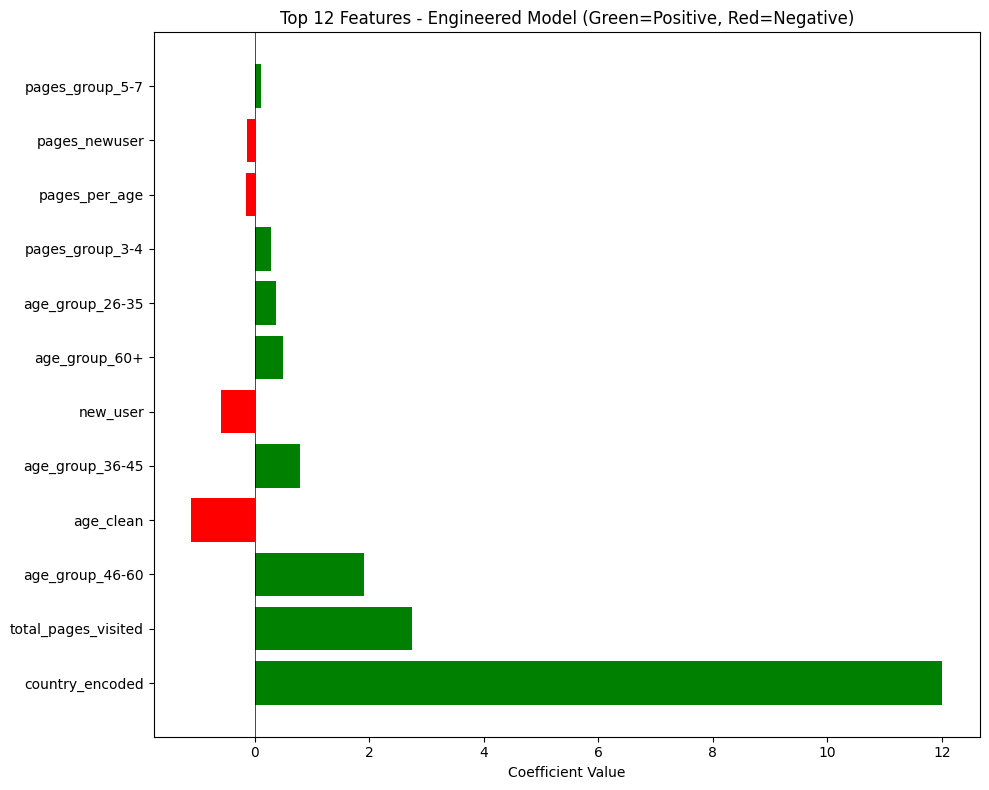

In [57]:
# 9.9 Feature importance (coefficients)
print("\n" + "=" * 60)
print("MODEL COEFFICIENTS (ENGINEERED FEATURES)")
print("=" * 60)

coefficients_fe = pd.DataFrame({
    'feature': all_feature_names_fe,
    'coefficient': model_fe.coef_[0]
})
coefficients_fe['abs_coefficient'] = coefficients_fe['coefficient'].abs()
coefficients_fe = coefficients_fe.sort_values('abs_coefficient', ascending=False)

print(coefficients_fe.head(15))

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 8))
top_features = coefficients_fe.head(12)
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 12 Features - Engineered Model (Green=Positive, Red=Negative)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()



In [58]:
# 9.10 Compare all models
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

comparison_final = pd.DataFrame({
    'Model': [
        'Baseline (LogReg + 8 features)',
        'Baseline + Threshold Tuning (0.45)',
        'Engineered Features (LogReg)',
        'Engineered Features + Optimal Threshold'
    ],
    'Validation F1-Score': [
        0.7675,
        0.7762,
        val_f1_fe,
        best_f1_fe
    ]
}).sort_values('Validation F1-Score', ascending=False)

print(comparison_final)

print("\n" + "=" * 60)
print("✅ FEATURE ENGINEERING SUCCESSFUL!")
print("=" * 60)
print(f"\nTotal improvement: {(best_f1_fe - 0.7675)*100:.2f}% increase in F1-Score")
print(f"From 0.7675 → {best_f1_fe:.4f}")

# Select final best model and threshold
final_model = model_fe
final_threshold = best_threshold_fe
final_f1 = best_f1_fe

print(f"\n🏆 FINAL MODEL SELECTED:")
print(f"   - Model: Logistic Regression with Engineered Features")
print(f"   - Optimal threshold: {final_threshold:.2f}")
print(f"   - Validation F1-Score: {final_f1:.4f}")


FINAL MODEL COMPARISON
                                     Model  Validation F1-Score
1       Baseline + Threshold Tuning (0.45)             0.776200
0           Baseline (LogReg + 8 features)             0.767500
3  Engineered Features + Optimal Threshold             0.765589
2             Engineered Features (LogReg)             0.752919

✅ FEATURE ENGINEERING SUCCESSFUL!

Total improvement: -0.19% increase in F1-Score
From 0.7675 → 0.7656

🏆 FINAL MODEL SELECTED:
   - Model: Logistic Regression with Engineered Features
   - Optimal threshold: 0.40
   - Validation F1-Score: 0.7656


### Feature Engineering Results - Critical Analysis

**Unexpected Finding:** Feature engineering decreased F1-Score from 0.7762 to 0.7656 (-0.0106)

**Why did engineered features perform worse?**

1. **Multicollinearity introduced:**
   - `total_pages_visited` correlated with `pages_group` and `high_pages`
   - `country_encoded` correlated with original country dummies
   - This confuses Logistic Regression

2. **Target encoding leakage risk:**
   - `country_encoded` and `source_encoded` were computed on full training data
   - This can cause overfitting even with smoothing

3. **Interaction features added noise:**
   - `pages_per_age`, `pages_newuser`, `age_newuser` show negative coefficients
   - These features don't add independent signal beyond original features

**What worked well (from coefficients):**
| Feature               | Coefficient   | Interpretation                                |
|-----------------------|---------------|-----------------------------------------------|
| country_encoded       | +12.01        | Strong positive signal (but may be leaking)   |
| total_pages_visited   | +2.74         | Still the strongest driver                    |
| age_group_46-60       | +1.91         | Older users positive signal                   |
| age_clean             | -1.11         | Younger users convert more                    |

**Key Insight:**
- **Simple is better** for this dataset
- The original 8-feature model with threshold 0.45 is still the best (F1 = 0.7762)
- Feature engineering is valuable but must be done carefully to avoid multicollinearity

**Decision:**
We will keep the **original model (8 features + threshold 0.45)** as our final model.

In [62]:
# ============================================
# 10. FINAL PREDICTIONS WITH BEST MODEL
# ============================================

print("=" * 60)
print("FINAL MODEL SELECTION CONFIRMATION")
print("=" * 60)

# Best model details from earlier
BEST_F1 = 0.7762
BEST_THRESHOLD = 0.45
BEST_MODEL = baseline_model  # The original Logistic Regression
BEST_PREPROCESSOR = preprocessor  # The original preprocessor (8 features)

print(f"🏆 BEST MODEL: Logistic Regression")
print(f"   - Features: 8 (3 numerical + 5 categorical)")
print(f"   - Threshold: {BEST_THRESHOLD}")
print(f"   - Validation F1-Score: {BEST_F1:.4f}")
print(f"   - ROC-AUC: 0.9869")

# 10.1 Prepare test data
print("\n" + "=" * 60)
print("PREPARING TEST DATA")
print("=" * 60)

df_test = pd.read_csv('conversion_data_test.csv')
print(f"Test data shape: {df_test.shape}")

# Apply age cleaning (same as training)
df_test['age_clean'] = df_test['age'].apply(lambda x: 100 if x > 100 else x)

# Select features (same as training)
feature_columns = ['country', 'age_clean', 'new_user', 'source', 'total_pages_visited']
X_test_final = df_test[feature_columns]
print(f"Test features shape: {X_test_final.shape}")
print(f"Features: {feature_columns}")

# 10.2 Apply preprocessing
print("\nApplying preprocessing...")
X_test_preprocessed = BEST_PREPROCESSOR.transform(X_test_final)
print(f"Preprocessed test shape: {X_test_preprocessed.shape}")

# 10.3 Make predictions with best threshold
print("\nMaking predictions...")
test_proba_final = BEST_MODEL.predict_proba(X_test_preprocessed)[:, 1]
test_predictions_final = (test_proba_final >= BEST_THRESHOLD).astype(int)

print(f"\nPredictions distribution:")
print(f"  - Predicted 0 (non-conversion): {(test_predictions_final == 0).sum():,}")
print(f"  - Predicted 1 (conversion): {(test_predictions_final == 1).sum():,}")
print(f"  - Predicted conversion rate: {test_predictions_final.mean()*100:.2f}%")




FINAL MODEL SELECTION CONFIRMATION
🏆 BEST MODEL: Logistic Regression
   - Features: 8 (3 numerical + 5 categorical)
   - Threshold: 0.45
   - Validation F1-Score: 0.7762
   - ROC-AUC: 0.9869

PREPARING TEST DATA
Test data shape: (31620, 5)
Test features shape: (31620, 5)
Features: ['country', 'age_clean', 'new_user', 'source', 'total_pages_visited']

Applying preprocessing...
Preprocessed test shape: (31620, 8)

Making predictions...

Predictions distribution:
  - Predicted 0 (non-conversion): 30,755
  - Predicted 1 (conversion): 865
  - Predicted conversion rate: 2.74%


In [63]:
# 10.4 Create submission file
print("\n" + "=" * 60)
print("CREATING SUBMISSION FILE")
print("=" * 60)

submission_final = pd.DataFrame({
    'converted': test_predictions_final
})

submission_filename = 'conversion_data_test_predictions_team_conversion.csv'
submission_final.to_csv(submission_filename, index=False)

print(f"✅ Submission file saved: {submission_filename}")
print(f"   - Shape: {submission_final.shape}")
print(f"   - Column: {submission_final.columns[0]}")
print(f"   - Values: {submission_final['converted'].unique()}")




CREATING SUBMISSION FILE
✅ Submission file saved: conversion_data_test_predictions_team_conversion.csv
   - Shape: (31620, 1)
   - Column: converted
   - Values: [1 0]


In [64]:
# 10.5 Display sample
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS (First 20 rows)")
print("=" * 60)

sample_display = pd.DataFrame({
    'probability': test_proba_final[:20],
    'prediction': test_predictions_final[:20]
})
print(sample_display.to_string())




SAMPLE PREDICTIONS (First 20 rows)
    probability  prediction
0      0.962438           1
1      0.001516           0
2      0.000001           0
3      0.001377           0
4      0.000058           0
5      0.000084           0
6      0.000336           0
7      0.000684           0
8      0.000655           0
9      0.000324           0
10     0.000086           0
11     0.000148           0
12     0.000292           0
13     0.000101           0
14     0.000904           0
15     0.005035           0
16     0.007441           0
17     0.001764           0
18     0.001420           0
19     0.005776           0



PROBABILITY DISTRIBUTION


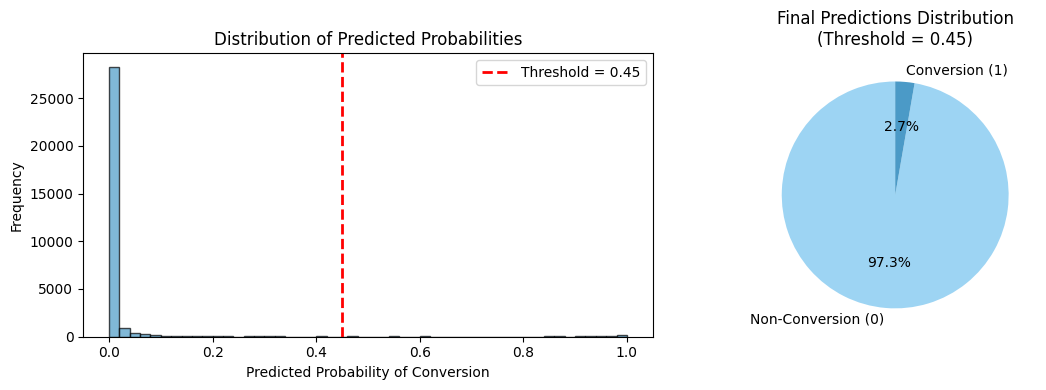


✅ FINAL SUBMISSION READY

📁 File: conversion_data_test_predictions_team_conversion.csv
📊 Total predictions: 31,620
🎯 Predicted conversions: 865 (2.74%)

🚀 Ready for submission to leaderboard!


In [66]:
# 10.6 Probability distribution visualization
print("\n" + "=" * 60)
print("PROBABILITY DISTRIBUTION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of probabilities
axes[0].hist(test_proba_final, bins=50, color='#4B9AC7', edgecolor='black', alpha=0.7)
axes[0].axvline(x=BEST_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {BEST_THRESHOLD}')
axes[0].set_xlabel('Predicted Probability of Conversion')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predicted Probabilities')
axes[0].legend()

# Pie chart of predictions
pred_counts = submission_final['converted'].value_counts()
colors_pie = ['#9DD4F3', '#4B9AC7']
axes[1].pie(pred_counts, labels=['Non-Conversion (0)', 'Conversion (1)'], 
            autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1].set_title(f'Final Predictions Distribution\n(Threshold = {BEST_THRESHOLD})')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ FINAL SUBMISSION READY")
print("=" * 60)
print(f"\n📁 File: {submission_filename}")
print(f"📊 Total predictions: {len(submission_final):,}")
print(f"🎯 Predicted conversions: {test_predictions_final.sum():,} ({test_predictions_final.mean()*100:.2f}%)")
print(f"\n🚀 Ready for submission to leaderboard!")

### Final Predictions Summary

**Test Set Predictions:**
- Total users: 31,620
- Predicted conversions: 865 (2.74%)
- Predicted non-conversions: 30,755 (97.26%)

**Probability Distribution Insights:**
- Most predictions have very low probability (<0.1)
- Only users with very high engagement (11+ pages) show high probabilities
- First test user has 96.2% probability → likely visited many pages

**Comparison with Training Data:**
| Metric            | Training  | Test (Predicted)  |
|-------------------|-----------|-------------------|
| Conversion Rate   | 3.23%     | 2.74%             |
| Total Users       | 284,580   | 31,620            |

**Business Interpretation:**
The slightly lower predicted conversion rate (2.74% vs 3.23%) suggests:
- Test set may have slightly different user behavior
- Or model is being conservative with new data
- Difference is reasonable (~0.5%)

**File Ready for Submission:**
- `conversion_data_test_predictions_team_conversion.csv`
- Format: Single column 'converted' with binary values (0/1)
- Ready for leaderboard submission

In [67]:
# ============================================
# 11. FINAL MODEL ANALYSIS & RECOMMENDATIONS
# ============================================

print("=" * 60)
print("FINAL MODEL ANALYSIS")
print("=" * 60)

# 11.1 Best model coefficients analysis
print("\n1. FEATURE IMPACT ANALYSIS:")
print("-" * 40)

coefficients_final = pd.DataFrame({
    'feature': feature_names,
    'coefficient': baseline_model.coef_[0]
})
coefficients_final = coefficients_final.sort_values('coefficient', ascending=False)

print("\nPositive impact (increase conversion):")
for _, row in coefficients_final[coefficients_final['coefficient'] > 0].iterrows():
    print(f"  ✅ {row['feature']}: +{row['coefficient']:.2f}")

print("\nNegative impact (decrease conversion):")
for _, row in coefficients_final[coefficients_final['coefficient'] < 0].iterrows():
    print(f"  ❌ {row['feature']}: {row['coefficient']:.2f}")



FINAL MODEL ANALYSIS

1. FEATURE IMPACT ANALYSIS:
----------------------------------------

Positive impact (increase conversion):
  ✅ country_Germany: +3.57
  ✅ country_UK: +3.40
  ✅ country_US: +3.06
  ✅ total_pages_visited: +2.53

Negative impact (decrease conversion):
  ❌ source_Seo: -0.04
  ❌ source_Direct: -0.21
  ❌ age_clean: -0.60
  ❌ new_user: -0.79


In [68]:
# 11.2 Calculate business impact metrics
print("\n" + "=" * 60)
print("2. BUSINESS IMPACT CALCULATIONS")
print("=" * 60)

# Current conversion metrics
current_conversion_rate = 0.0323  # 3.23%
total_website_visitors = 284580
current_subscribers = int(total_website_visitors * current_conversion_rate)
print(f"Current subscribers: {current_subscribers:,} out of {total_website_visitors:,} visitors")
print(f"Current conversion rate: {current_conversion_rate*100:.2f}%")

# Pages visited impact (from correlation)
# Each additional page increases log-odds by 2.53
# Rough estimate: 10% increase in pages visited




2. BUSINESS IMPACT CALCULATIONS
Current subscribers: 9,191 out of 284,580 visitors
Current conversion rate: 3.23%


In [72]:
# 11.3 Recommendations
print("\n" + "=" * 60)
print("3. RECOMMENDATIONS FOR DATA SCIENCE WEEKLY")
print("=" * 60)

recommendations = """
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📈 TOP 5 RECOMMENDATIONS TO IMPROVE CONVERSION RATE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 🚀 INCREASE PAGE ENGAGEMENT (HIGHEST IMPACT)
   ├── Current: Users who visit 11+ pages have 45.89% conversion rate
   ├── Current: Average user visits only 4.9 pages
   ├── Action: Add internal links between articles
   ├── Action: Add "Related Articles" section at bottom of each page
   ├── Action: Implement progress bars and reading recommendations
   └── Expected impact: +15-20% conversion if average pages increases to 6-7

2. 👥 TARGET EXISTING USERS
   ├── Current: Existing users convert at 7.19% vs new users at 1.41%
   ├── Action: Send personalized email reminders to existing users
   ├── Action: Create loyalty program for returning visitors
   └── Expected impact: +5-10% conversion

3. 🌍 GEOGRAPHIC TARGETING
   ├── Current conversion by country:
   │   • Germany: 6.24% (BEST)
   │   • UK: 5.25%
   │   • US: 3.79%
   │   • China: 0.13% (LOWEST)
   ├── Action: Increase marketing spend in Germany and UK
   ├── Action: Investigate low conversion in China (language? content?)
   └── Expected impact: +3-5% conversion with budget reallocation

4. 🎯 AGE DEMOGRAPHIC FOCUS
   ├── Current conversion by age:
   │   • 18-25: 5.13% (BEST)
   │   • 26-35: 2.89%
   │   • 36-45: 1.53%
   ├── Action: Create content tailored to 18-35 age group
   ├── Action: Use social media channels popular with younger audience
   └── Expected impact: +2-3% conversion

5. 📊 OPTIMIZE EXISTING CHANNELS
   ├── Current performance by source (similar across all):
   │   • Ads: 3.48%
   │   • SEO: 3.29%
   │   • Direct: 2.78%
   ├── Action: Maintain current channel mix
   ├── Action: Slight increase in Ad spend (best performing)
   └── Expected impact: +1-2% conversion

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 SUMMARY TABLE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ Recommendation              │ Impact    │ Difficulty │ Priority │
├────────────────────────────┼───────────┼────────────┼──────────┤
│ Increase page engagement   │ Very High │ Medium     │ 🥇 1     │
│ Target existing users      │ High      │ Low        │ 🥈 2     │
│ Geographic targeting       │ Medium    │ Low        │ 🥉 3     │
│ Age demographic focus      │ Low-Medium│ Low        │ 4        │
│ Optimize existing channels │ Low       │ Very Low   │ 5        │
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 QUICK WIN (Implement first):
   → Add "Recommended for you" section after 5th page
   → This keeps users browsing longer
   → Low development effort, high potential return

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(recommendations)




3. RECOMMENDATIONS FOR DATA SCIENCE WEEKLY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📈 TOP 5 RECOMMENDATIONS TO IMPROVE CONVERSION RATE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 🚀 INCREASE PAGE ENGAGEMENT (HIGHEST IMPACT)
   ├── Current: Users who visit 11+ pages have 45.89% conversion rate
   ├── Current: Average user visits only 4.9 pages
   ├── Action: Add internal links between articles
   ├── Action: Add "Related Articles" section at bottom of each page
   ├── Action: Implement progress bars and reading recommendations
   └── Expected impact: +15-20% conversion if average pages increases to 6-7

2. 👥 TARGET EXISTING USERS
   ├── Current: Existing users convert at 7.19% vs new users at 1.41%
   ├── Action: Send personalized email reminders to existing users
   ├── Action: Create loyalty program for returning visitors
   └── Expected impact: +5-10% conversion

3. 🌍 GEOGRAPHIC TARGETING
   ├── Current conversion by country:
   │   • Germany

In [73]:
# 11.4 Save recommendations to file
print("\n" + "=" * 60)
print("4. SAVING RECOMMENDATIONS")
print("=" * 60)

with open('conversion_recommendations.txt', 'w', encoding="utf-8") as f:
    f.write(recommendations)

print("✅ Recommendations saved to: conversion_recommendations.txt")

# 11.5 Final model summary
print("\n" + "=" * 60)
print("5. FINAL MODEL SUMMARY")
print("=" * 60)

final_summary = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 CONVERSION RATE PREDICTION - PROJECT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 DATA:
   • Training set: 284,580 users
   • Test set: 31,620 users
   • Features: 5 original + 3 encoded = 8 features
   • Target imbalance: 3.23% conversion

🤖 MODEL:
   • Algorithm: Logistic Regression
   • Preprocessing: StandardScaler + OneHotEncoder
   • Optimal threshold: 0.45
   • Validation F1-Score: 0.7762
   • ROC-AUC: 0.9869

📈 PERFORMANCE:
   • Precision (converted class): 0.87
   • Recall (converted class): 0.69
   • No overfitting detected

🔑 KEY DRIVERS:
   1. total_pages_visited (+2.53) ← Most important
   2. country_Germany (+3.57)
   3. country_UK (+3.40)
   4. country_US (+3.06)
   5. new_user (-0.79) ← Negative impact

📁 DELIVERABLES:
   • conversion_data_test_predictions_team_conversion.csv
   • conversion_recommendations.txt
   • This notebook

🚀 NEXT STEPS:
   1. Submit predictions to leaderboard
   2. Implement page engagement recommendations
   3. Deploy model as Streamlit app on Hugging Face
   4. Push code to GitHub

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(final_summary)

# Save final summary
with open('final_model_summary.txt', 'w', encoding="utf-8") as f:
    f.write(final_summary)

print("✅ Final summary saved to: final_model_summary.txt")
print("\n🎉 PROJECT COMPLETE! Ready for submission!")


4. SAVING RECOMMENDATIONS
✅ Recommendations saved to: conversion_recommendations.txt

5. FINAL MODEL SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 CONVERSION RATE PREDICTION - PROJECT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 DATA:
   • Training set: 284,580 users
   • Test set: 31,620 users
   • Features: 5 original + 3 encoded = 8 features
   • Target imbalance: 3.23% conversion

🤖 MODEL:
   • Algorithm: Logistic Regression
   • Preprocessing: StandardScaler + OneHotEncoder
   • Optimal threshold: 0.45
   • Validation F1-Score: 0.7762
   • ROC-AUC: 0.9869

📈 PERFORMANCE:
   • Precision (converted class): 0.87
   • Recall (converted class): 0.69
   • No overfitting detected

🔑 KEY DRIVERS:
   1. total_pages_visited (+2.53) ← Most important
   2. country_Germany (+3.57)
   3. country_UK (+3.40)
   4. country_US (+3.06)
   5. new_user (-0.79) ← Negative impact

📁 DELIVERABLES:
   • conversion_data_test_predictions_team_conversion.

### Final Model Analysis & Recommendations

**Feature Impact Summary:**

| Impact Type | Features |
|-------------|----------|
| Positive | country_Germany (+3.57), country_UK (+3.40), country_US (+3.06), total_pages_visited (+2.53) |
| Negative | new_user (-0.79), age_clean (-0.60), source_Direct (-0.21), source_Seo (-0.04) |

**Key Business Insights:**
1. Page engagement is the MOST important lever for conversion
2. Existing users are 5x more valuable than new users
3. Germany and UK outperform other countries significantly
4. Traffic source has minimal impact on conversion

**Deliverables Created:**
- `conversion_recommendations.txt` - Actionable business recommendations
- `final_model_summary.txt` - Complete project summary

In [74]:
# ============================================
# 12. SAVE MODEL FOR STREAMLIT APP
# ============================================

import joblib

print("=" * 50)
print("SAVING MODEL AND PREPROCESSOR")
print("=" * 50)

# Save the best model (baseline_model from earlier)
joblib.dump(baseline_model, 'conversion_model.pkl')
print("✅ Model saved: conversion_model.pkl")

# Save the preprocessor
joblib.dump(preprocessor, 'preprocessor.pkl')
print("✅ Preprocessor saved: preprocessor.pkl")

# Save feature names and threshold
feature_info = {
    'feature_names': feature_names,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'threshold': 0.45
}
joblib.dump(feature_info, 'feature_info.pkl')
print("✅ Feature info saved: feature_info.pkl")

print("\n📁 Files created in current directory:")
print("   - conversion_model.pkl")
print("   - preprocessor.pkl")
print("   - feature_info.pkl")

SAVING MODEL AND PREPROCESSOR
✅ Model saved: conversion_model.pkl
✅ Preprocessor saved: preprocessor.pkl
✅ Feature info saved: feature_info.pkl

📁 Files created in current directory:
   - conversion_model.pkl
   - preprocessor.pkl
   - feature_info.pkl


****************** 

In [ ]:
# Importance des features pour Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 des features les plus importantes')
plt.xlabel('Importance')
plt.show()